In [95]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [96]:
# Load dataset
df = pd.read_csv('../data/movies.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Users: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
print()
df.head(10)

Dataset Shape: (4803, 20)
Total Users: 4,803
Total Features: 20



,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124
5,258000000,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""na...",http://www.sonypictures.com/movies/spider-man3/,559,"[{""id"": 851, ""name"": ""dual identity""}, {""id"": ...",en,Spider-Man 3,The seemingly invincible Spider-Man goes up ag...,115.699814,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-01,890871626,139.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,The battle within.,Spider-Man 3,5.9,3576
6,260000000,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 10751...",http://disney.go.com/disneypictures/tangled/,38757,"[{""id"": 1562, ""name"": ""hostage""}, {""id"": 2343,...",en,Tangled,When the kingdom's most wanted-and most charmi...,48.681969,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2010-11-24,591794936,100.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,They're taking adventure to new lengths.,Tangled,7.4,3330
7,280000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://marvel.com/movies/movie/193/avenge

In [97]:
# Data types and info
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)
print()
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print()
print("=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
df.describe()

DATA TYPES
budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
dtype: object

MISSING VALUES
budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0


,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [98]:
# missing values
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)


Missing Values in Each Column:
budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64


In [99]:
# ── 1. Drop homepage (64% missing, not useful for recommender) ──
df.drop(columns=['homepage'], inplace=True)
print(f"After dropping homepage: {df.shape}")

After dropping homepage: (4803, 19)


In [100]:
# ── 2. Fill tagline and overview with empty string ──
df['tagline'] = df['tagline'].fillna('')
df['overview'] = df['overview'].fillna('')
print(f"Nulls in tagline: {df['tagline'].isnull().sum()}")
print(f"Nulls in overview: {df['overview'].isnull().sum()}")


Nulls in tagline: 0
Nulls in overview: 0


In [101]:
# missing values
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)


Missing Values in Each Column:
budget                  0
genres                  0
id                      0
keywords                0
original_language       0
original_title          0
overview                0
popularity              0
production_companies    0
production_countries    0
release_date            1
revenue                 0
runtime                 2
spoken_languages        0
status                  0
tagline                 0
title                   0
vote_average            0
vote_count              0
dtype: int64


In [102]:
# release_date — drop null row, parse to datetime, extract features
df.dropna(subset=['release_date'], inplace=True)
df['release_date']  = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']  = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

In [103]:
# missing values
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
budget                  0
genres                  0
id                      0
keywords                0
original_language       0
original_title          0
overview                0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 2
spoken_languages        0
status                  0
tagline                 0
title                   0
vote_average            0
vote_count              0
release_year            0
release_month           0
dtype: int64


In [104]:
# 4. runtime — treat 0 as missing, fill with median
df['runtime'] = df['runtime'].replace(0, np.nan)
df['runtime'] = df['runtime'].fillna(df['runtime'].median())

In [105]:
# budget & revenue — treat 0 as missing
df['budget']  = df['budget'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)

# Keep only released movies
df = df[df['status'] == 'Released'].copy()

print(df.shape)

(4794, 21)


In [106]:
df.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,release_year,release_month
0,237000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",...,2.787965e+09,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,2009,12
1,300000000.0,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",...,9.610000e+08,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,2007,5
2,245000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",...,8.806746e+08,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,2015,10
3,250000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",...,1.084939e+09,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,2012,7
4,260000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",...,2.841391e+08,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,2012,3


In [107]:
import ast
from collections import Counter

# Function to parse JSON strings and extract 'name' values
def parse_json_col(text):
    try:
        items = ast.literal_eval(text)
        return [item['name'] for item in items]
    except:
        return []
    
# parse genres, keywords, production_companies, production_countries, spoken_languages
df['genres'] = df['genres'].apply(parse_json_col)
df['keywords'] = df['keywords'].apply(parse_json_col)
df['production_companies'] = df['production_companies'].apply(parse_json_col)
df['production_countries'] = df['production_countries'].apply(parse_json_col)
df['spoken_languages'] = df['spoken_languages'].apply(parse_json_col)



In [108]:
json_cols = ['genres', 'keywords', 'production_companies', 
             'production_countries', 'spoken_languages']

print("── Type check (should all be list) ──")
for col in json_cols:
    print(f"{col:25s} → type of first value: {type(df[col][0])}")

print("\n── Avg items per movie ──")
for col in json_cols:
    avg = df[col].apply(len).mean()
    print(f"{col:25s} → avg: {avg:.2f}")

── Type check (should all be list) ──
genres                    → type of first value: <class 'list'>
keywords                  → type of first value: <class 'list'>
production_companies      → type of first value: <class 'list'>
production_countries      → type of first value: <class 'list'>
spoken_languages          → type of first value: <class 'list'>

── Avg items per movie ──
genres                    → avg: 2.53
keywords                  → avg: 7.54
production_companies      → avg: 2.85
production_countries      → avg: 1.34
spoken_languages          → avg: 1.45


In [109]:
all_genres = [g for sublist in df['genres'] for g in sublist]
top_genres = Counter(all_genres).most_common(10)

print("── Top 10 Genres ──")
for genre, count in top_genres:
    print(f"  {genre:20s} : {count}")

── Top 10 Genres ──
  Drama                : 2292
  Comedy               : 1718
  Thriller             : 1272
  Action               : 1153
  Romance              : 893
  Adventure            : 790
  Crime                : 696
  Science Fiction      : 534
  Horror               : 519
  Family               : 512


In [110]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4794 entries, 0 to 4802
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   budget                3763 non-null   float64       
 1   genres                4794 non-null   object        
 2   id                    4794 non-null   int64         
 3   keywords              4794 non-null   object        
 4   original_language     4794 non-null   object        
 5   original_title        4794 non-null   object        
 6   overview              4794 non-null   object        
 7   popularity            4794 non-null   float64       
 8   production_companies  4794 non-null   object        
 9   production_countries  4794 non-null   object        
 10  release_date          4794 non-null   datetime64[ns]
 11  revenue               3375 non-null   float64       
 12  runtime               4794 non-null   float64       
 13  spoken_languages      4

In [111]:
df.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,release_year,release_month
0,237000000.0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[culture clash, future, space war, space colon...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",...,2.787965e+09,162.0,"[English, Español]",Released,Enter the World of Pandora.,Avatar,7.2,11800,2009,12
1,300000000.0,"[Adventure, Fantasy, Action]",285,"[ocean, drug abuse, exotic island, east india ...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...",[United States of America],...,9.610000e+08,169.0,[English],Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,2007,5
2,245000000.0,"[Action, Adventure, Crime]",206647,"[spy, based on novel, secret agent, sequel, mi...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[Columbia Pictures, Danjaq, B24]","[United Kingdom, United States of America]",...,8.806746e+08,148.0,"[Français, English, Español, Italiano, Deutsch]",Released,A Plan No One Escapes,Spectre,6.3,4466,2015,10
3,250000000.0,"[Action, Crime, Drama, Thriller]",49026,"[dc comics, crime fighter, terrorist, secret i...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...",[United States of America],...,1.084939e+09,165.0,[English],Released,The Legend Ends,The Dark Knight Rises,7.6,9106,2012,7
4,260000000.0,"[Action, Adventure, Science Fiction]",49529,"[based on novel, mars, medallion, space travel...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,[Walt Disney Pictures],[United States of America],...,2.841391e+08,132.0,[English],Released,"Lost in our world, found in another.",John Carter,6.1,2124,2012,3


In [112]:
credits = pd.read_csv('../data/credits.csv')

print(f"Shape       : {credits.shape}")
print(f"Columns     : {credits.columns.tolist()}")
print(f"Dtypes      :\n{credits.dtypes}")
print(f"\nMissing values:\n{credits.isnull().sum()}")
print(f"\nDuplicates  : {credits.duplicated().sum()}")
print(f"\nSample cast :\n{credits['cast'][0][:300]}")
print(f"\nSample crew :\n{credits['crew'][0][:300]}")

Shape       : (4803, 4)
Columns     : ['movie_id', 'title', 'cast', 'crew']
Dtypes      :
movie_id     int64
title       object
cast        object
crew        object
dtype: object

Missing values:
movie_id    0
title       0
cast        0
crew        0
dtype: int64

Duplicates  : 0

Sample cast :
[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_

Sample crew :
[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c


In [113]:
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [114]:
# Parse cast (Top 5 actors only)

import ast

def get_top_cast(text, top_n=5):
    try:
        cast_list = ast.literal_eval(text)
        # cast is already ordered by billing, take top N
        return [member['name'] for member in cast_list[:top_n]]
    except:
        return []

credits['cast'] = credits['cast'].apply(get_top_cast)

print("Sample cast (top 5):")
print(credits['cast'].head(3).values)
print(f"\nEmpty cast rows: {credits['cast'].apply(lambda x: len(x)==0).sum()}")

Sample cast (top 5):
[list(['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver', 'Stephen Lang', 'Michelle Rodriguez'])
 list(['Johnny Depp', 'Orlando Bloom', 'Keira Knightley', 'Stellan Skarsgård', 'Chow Yun-fat'])
 list(['Daniel Craig', 'Christoph Waltz', 'Léa Seydoux', 'Ralph Fiennes', 'Monica Bellucci'])]

Empty cast rows: 43


In [115]:
def get_directors(text):
    try:
        crew_list = ast.literal_eval(text)
        return [member['name'] for member in crew_list if member['job'] == 'Director']
    except:
        return []

credits['director'] = credits['crew'].apply(get_directors)
credits.drop(columns=['crew'], inplace=True)  # no longer needed

print("Sample directors:")
print(credits['director'].head(3).values)
print(f"\nMovies with no director found: {credits['director'].apply(lambda x: len(x)==0).sum()}")

Sample directors:
[list(['James Cameron']) list(['Gore Verbinski']) list(['Sam Mendes'])]

Movies with no director found: 30


In [116]:
print(f"Credits shape : {credits.shape}")
print(f"Columns       : {credits.columns.tolist()}")
print(f"\nPreview:")
credits.head(3)

Credits shape : (4803, 4)
Columns       : ['movie_id', 'title', 'cast', 'director']

Preview:


,movie_id,title,cast,director
0,19995,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron]
1,285,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley, ...",[Gore Verbinski]
2,206647,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",[Sam Mendes]


In [117]:
# Check if 'id' in movies matches 'movie_id' in credits
# Movies 'id' is int64, Credits 'movie_id' is int64, so they should be compatible for merging
# So we can merge on df['id'] and credits['movie_id'] without type issues

print("── Movies 'id' column ──")
print(f"Dtype  : {df['id'].dtype}")
print(f"Sample : {df['id'].head(5).values}")

print("\n── Credits 'movie_id' column ──")
print(f"Dtype  : {credits['movie_id'].dtype}")
print(f"Sample : {credits['movie_id'].head(5).values}")

print(f"\nUnique movies  : {df['id'].nunique()}")
print(f"Unique credits : {credits['movie_id'].nunique()}")

# Check how many IDs match
common = set(df['id']).intersection(set(credits['movie_id']))
print(f"Common IDs     : {len(common)}")

── Movies 'id' column ──
Dtype  : int64
Sample : [ 19995    285 206647  49026  49529]

── Credits 'movie_id' column ──
Dtype  : int64
Sample : [ 19995    285 206647  49026  49529]

Unique movies  : 4794
Unique credits : 4803
Common IDs     : 4794


In [118]:
# credits has its own 'title' column — drop if present to avoid duplication after merge
if 'title' in credits.columns:
    credits.drop(columns=['title'], inplace=True)

print(f"Credits columns after drop : {credits.columns.tolist()}")

Credits columns after drop : ['movie_id', 'cast', 'director']


In [119]:
# Merge on movies 'id' and credits 'movie_id'
# Use left join to keep all movies, even those without credits info (will have NaN for cast/director)
movies = df.merge(credits, left_on='id', right_on='movie_id', how='left')
movies.drop(columns=['movie_id'], inplace=True)  # redundant after merge

print(f"Shape after merge : {movies.shape}")
print(f"Columns           : {movies.columns.tolist()}")

Shape after merge : (4794, 23)
Columns           : ['budget', 'genres', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'release_year', 'release_month', 'cast', 'director']


In [120]:
print("── Nulls after merge ──")
null_check = movies.isnull().sum()
print(null_check[null_check > 0])

print("\n── Sample merged row ──")

# Handle possible title rename after merge (title/title_x/title_y).
title_col = next((c for c in ['title', 'title_x', 'title_y'] if c in movies.columns), None)
preview_cols = [title_col, 'genres', 'cast', 'director', 'keywords', 'overview']
preview_cols = [c for c in preview_cols if c is not None and c in movies.columns]

print(f"Using columns: {preview_cols}")
movies[preview_cols].head(3)

── Nulls after merge ──
budget     1031
revenue    1419
dtype: int64

── Sample merged row ──
Using columns: ['title', 'genres', 'cast', 'director', 'keywords', 'overview']


,title,genres,cast,director,keywords,overview
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron],"[culture clash, future, space war, space colon...","In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[Johnny Depp, Orlando Bloom, Keira Knightley, ...",[Gore Verbinski],"[ocean, drug abuse, exotic island, east india ...","Captain Barbossa, long believed to be dead, ha..."
2,Spectre,"[Action, Adventure, Crime]","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",[Sam Mendes],"[spy, based on novel, secret agent, sequel, mi...",A cryptic message from Bond’s past sends him o...


In [121]:
# Some movies may not have matched — fill with empty list
movies['cast']     = movies['cast'].apply(lambda x: x if isinstance(x, list) else [])
movies['director'] = movies['director'].apply(lambda x: x if isinstance(x, list) else [])

print(f"Null cast     : {movies['cast'].isnull().sum()}")
print(f"Null director : {movies['director'].isnull().sum()}")
print(f"\nFinal shape   : {movies.shape}")
print(f"\nPreview:")

title_col = next((c for c in ['title', 'title_x', 'title_y'] if c in movies.columns), None)
preview_cols = [title_col, 'genres', 'cast', 'director', 'keywords', 'overview', 'release_year']
preview_cols = [c for c in preview_cols if c is not None and c in movies.columns]

print(f"Using columns: {preview_cols}")
movies[preview_cols].head(3)

Null cast     : 0
Null director : 0

Final shape   : (4794, 23)

Preview:
Using columns: ['title', 'genres', 'cast', 'director', 'keywords', 'overview', 'release_year']


,title,genres,cast,director,keywords,overview,release_year
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron],"[culture clash, future, space war, space colon...","In the 22nd century, a paraplegic Marine is di...",2009
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[Johnny Depp, Orlando Bloom, Keira Knightley, ...",[Gore Verbinski],"[ocean, drug abuse, exotic island, east india ...","Captain Barbossa, long believed to be dead, ha...",2007
2,Spectre,"[Action, Adventure, Crime]","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",[Sam Mendes],"[spy, based on novel, secret agent, sequel, mi...",A cryptic message from Bond’s past sends him o...,2015


In [122]:
# Clean up title columns permanently (safe on reruns)
if 'title_y' in movies.columns:
    movies.drop(columns=['title_y'], inplace=True)

if 'title_x' in movies.columns and 'title' not in movies.columns:
    movies.rename(columns={'title_x': 'title'}, inplace=True)
elif 'title_x' in movies.columns and 'title' in movies.columns:
    movies.drop(columns=['title_x'], inplace=True)

print(f"Columns : {movies.columns.tolist()}")
print(f"Shape   : {movies.shape}")

Columns : ['budget', 'genres', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'release_year', 'release_month', 'cast', 'director']
Shape   : (4794, 23)


In [123]:
# Quick check before running Step 6 cells
print(f"Shape         : {movies.shape}")
print(f"Title sample  : {movies['title'][0]}")       # should be 'avatar' after step 6
print(f"Genres sample : {movies['genres'][0]}")      # should be ['action','adventure',...] after step 6
print(f"Cast sample   : {movies['cast'][0]}")        # should be ['samworthington',...] after step 6

Shape         : (4794, 23)
Title sample  : Avatar
Genres sample : ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
Cast sample   : ['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver', 'Stephen Lang', 'Michelle Rodriguez']


In [124]:
# View first 10 rows
movies.head(10)

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,...,spoken_languages,status,tagline,title,vote_average,vote_count,release_year,release_month,cast,director
0,237000000.0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[culture clash, future, space war, space colon...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",...,"[English, Español]",Released,Enter the World of Pandora.,Avatar,7.2,11800,2009,12,"[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron]
1,300000000.0,"[Adventure, Fantasy, Action]",285,"[ocean, drug abuse, exotic island, east india ...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...",[United States of America],...,[English],Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,2007,5,"[Johnny Depp, Orlando Bloom, Keira Knightley, ...",[Gore Verbinski]
2,245000000.0,"[Action, Adventure, Crime]",206647,"[spy, based on novel, secret agent, sequel, mi...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[Columbia Pictures, Danjaq, B24]","[United Kingdom, United States of America]",...,"[Français, English, Español, Italiano, Deutsch]",Released,A Plan No One Escapes,Spectre,6.3,4466,2015,10,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",[Sam Mendes]
3,250000000.0,"[Action, Crime, Drama, Thriller]",49026,"[dc comics, crime fighter, terrorist, secret i...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...",[United States of America],...,[English],Released,The Legend Ends,The Dark Knight Rises,7.6,9106,2012,7,"[Christian Bale, Michael Caine, Gary Oldman, A...",[Christopher Nolan]
4,260000000.0,"[Action, Adventure, Science Fiction]",49529,"[based on novel, mars, medallion, space travel...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,[Walt Disney Pictures],[United States of America],...,[English],Released,"Lost in our world, found in another.",John Carter,6.1,2124,2012,3,"[Taylor Kitsch, Lynn Collins, Samantha Morton,...",[Andrew Stanton]
5,258000000.0,"[Fantasy, Action, Adventure]",559,"[dual identity, amnesia, sandstorm, love of on...",en,Spider-Man 3,The seemingly invincible Spider-Man goes up ag...,115.699814,"[Columbia Pictures, Laura Ziskin Productions, ...",[United States of America],...,"[English, Français]",Released,The battle within.,Spider-Man 3,5.9,3576,2007,5,"[Tobey Maguire, Kirsten Dunst, James Franco, T...",[Sam Raimi]
6,260000000.0,"[Animation, Family]",38757,"[hostage, magic, horse, fairy tale, musical, p...",en,Tangled,When the kingdom's most wanted-and most charmi...,48.681969,"[Walt Disney Pictures, Walt Disney Animation S...",[United States of America],...,[English],Released,They're taking adventure to new lengths.,Tangled,7.4,3330,2010,11,"[Zachary Levi, Mandy Moore, Donna Murphy, Ron ...","[Byron Howard, Nathan Greno]"
7,280000000.0,"[Action, Adventure, Science Fiction]",99861,"[marvel comic, sequel, superhero, based on com...",en,Avengers: Age of Ultron,When Tony Stark tries to jumpstart a dormant p...,134.279229,"[Marvel Studios, Prime Focus, Revolution Sun S...",[United States of America],...,[English],Released,A New Age Has Come.,Avengers: Age of Ultron,7.3,6767,2015,4,"[Robert Downey Jr., Chris Hemsworth, Mark Ruff...",[Joss Whedon]
8,250000000.0,"[Adventure, Fantasy, Family]",767,"[witch, magic, broom, school of witchcraft, wi...",en,Harry Potter and the Half-Blood Prince,"As Harry begins his sixth year at Hogwarts, he...",98.885637,"[Warner Bros., Heyday Films]","[United Kingdom, United States of America]",...,[English],Released,Dark Secrets Revealed,Harry Potter and the 

In [125]:
import re

# re means regular expressions, which can be used for text cleaning and manipulation. We might use it later to clean movie titles, overviews, or other text fields by removing special characters, extra spaces, or performing other transformations.
# re used for text cleaning and manipulation, such as removing special characters, extra spaces, or performing other transformations on movie titles, overviews, or other text fields.

import re
# Lowercase title, overview, tagline
text_cols = ['title', 'overview', 'tagline']

for col in text_cols:
    movies[col] = movies[col].str.lower()

print("── Sample after lowercase ──")
print(f"title   : {movies['title'][0]}")
print(f"overview: {movies['overview'][0][:100]}")
print(f"tagline : {movies['tagline'][0]}")

# this code used for debugging and checking the tagline column after lowercase transformation 

── Sample after lowercase ──
title   : avatar
overview: in the 22nd century, a paraplegic marine is dispatched to the moon pandora on a unique mission, but 
tagline : enter the world of pandora.


In [126]:
# Remove Punctuation & Special Characters
def clean_text(text):
    if isinstance(text, str):
        text = re.sub(r'[^a-z0-9\s]', '', text) 
# keep only letters, numbers, spaces. It removes all punctuation and special characters, leaving only lowercase letters, digits, and spaces. This helps standardize the text for better matching in the recommender system.
        text = re.sub(r'\s+', ' ', text).strip()  
# collapse multiple spaces. It replaces multiple consecutive whitespace characters with a single space and removes leading/trailing spaces. This further cleans the text and ensures consistent spacing, which can improve matching in the recommender system.
    return text

for col in text_cols:
    movies[col] = movies[col].apply(clean_text)

print("── Sample after punctuation removal ──")
print(f"title   : {movies['title'][0]}")
print(f"overview: {movies['overview'][0][:100]}")
print(f"tagline : {movies['tagline'][0]}")

── Sample after punctuation removal ──
title   : avatar
overview: in the 22nd century a paraplegic marine is dispatched to the moon pandora on a unique mission but be
tagline : enter the world of pandora


In [127]:
#  Normalize List Columns (Remove spaces within names)
# "Science Fiction" → "sciencefiction"
# "Sam Worthington" → "samworthington"
# This ensures each item is treated as ONE token by the recommender

list_cols = ['genres', 'keywords', 'cast', 'director', 
             'production_companies', 'production_countries', 'spoken_languages']

def normalize_list(lst):
    return [item.lower().replace(' ', '') for item in lst]

for col in list_cols:
    movies[col] = movies[col].apply(normalize_list)

print("── Sample after list normalization ──")
print(f"genres   : {movies['genres'][0]}")
print(f"keywords : {movies['keywords'][0][:5]}")
print(f"cast     : {movies['cast'][0]}")
print(f"director : {movies['director'][0]}")

── Sample after list normalization ──
genres   : ['action', 'adventure', 'fantasy', 'sciencefiction']
keywords : ['cultureclash', 'future', 'spacewar', 'spacecolony', 'society']
cast     : ['samworthington', 'zoesaldana', 'sigourneyweaver', 'stephenlang', 'michellerodriguez']
director : ['jamescameron']


In [128]:
# Verify No Nulls Introduced

print("── Null check after normalization ──")
check_cols = text_cols + list_cols
for col in check_cols:
    print(f"{col:25s} → nulls: {movies[col].isnull().sum()}")

── Null check after normalization ──
title                     → nulls: 0
overview                  → nulls: 0
tagline                   → nulls: 0
genres                    → nulls: 0
keywords                  → nulls: 0
cast                      → nulls: 0
director                  → nulls: 0
production_companies      → nulls: 0
production_countries      → nulls: 0
spoken_languages          → nulls: 0


In [129]:
# Preview Final Normalized Data
print("── Sample normalized row ──")
sample = movies[['title', 'overview', 'tagline', 'genres', 
                  'keywords', 'cast', 'director']].iloc[0]

for col, val in sample.items():
    print(f"\n{col:10s}: {val if isinstance(val, str) else val}")

── Sample normalized row ──

title     : avatar

overview  : in the 22nd century a paraplegic marine is dispatched to the moon pandora on a unique mission but becomes torn between following orders and protecting an alien civilization

tagline   : enter the world of pandora

genres    : ['action', 'adventure', 'fantasy', 'sciencefiction']

keywords  : ['cultureclash', 'future', 'spacewar', 'spacecolony', 'society', 'spacetravel', 'futuristic', 'romance', 'space', 'alien', 'tribe', 'alienplanet', 'cgi', 'marine', 'soldier', 'battle', 'loveaffair', 'antiwar', 'powerrelations', 'mindandsoul', '3d']

cast      : ['samworthington', 'zoesaldana', 'sigourneyweaver', 'stephenlang', 'michellerodriguez']

director  : ['jamescameron']


In [130]:
movies.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,...,spoken_languages,status,tagline,title,vote_average,vote_count,release_year,release_month,cast,director
0,237000000.0,"[action, adventure, fantasy, sciencefiction]",19995,"[cultureclash, future, spacewar, spacecolony, ...",en,Avatar,in the 22nd century a paraplegic marine is dis...,150.437577,"[ingeniousfilmpartners, twentiethcenturyfoxfil...","[unitedstatesofamerica, unitedkingdom]",...,"[english, español]",Released,enter the world of pandora,avatar,7.2,11800,2009,12,"[samworthington, zoesaldana, sigourneyweaver, ...",[jamescameron]
1,300000000.0,"[adventure, fantasy, action]",285,"[ocean, drugabuse, exoticisland, eastindiatrad...",en,Pirates of the Caribbean: At World's End,captain barbossa long believed to be dead has ...,139.082615,"[waltdisneypictures, jerrybruckheimerfilms, se...",[unitedstatesofamerica],...,[english],Released,at the end of the world the adventure begins,pirates of the caribbean at worlds end,6.9,4500,2007,5,"[johnnydepp, orlandobloom, keiraknightley, ste...",[goreverbinski]
2,245000000.0,"[action, adventure, crime]",206647,"[spy, basedonnovel, secretagent, sequel, mi6, ...",en,Spectre,a cryptic message from bonds past sends him on...,107.376788,"[columbiapictures, danjaq, b24]","[unitedkingdom, unitedstatesofamerica]",...,"[français, english, español, italiano, deutsch]",Released,a plan no one escapes,spectre,6.3,4466,2015,10,"[danielcraig, christophwaltz, léaseydoux, ralp...",[sammendes]
3,250000000.0,"[action, crime, drama, thriller]",49026,"[dccomics, crimefighter, terrorist, secretiden...",en,The Dark Knight Rises,following the death of district attorney harve...,112.312950,"[legendarypictures, warnerbros., dcentertainme...",[unitedstatesofamerica],...,[english],Released,the legend ends,the dark knight rises,7.6,9106,2012,7,"[christianbale, michaelcaine, garyoldman, anne...",[christophernolan]
4,260000000.0,"[action, adventure, sciencefiction]",49529,"[basedonnovel, mars, medallion, spacetravel, p...",en,John Carter,john carter is a warweary former military capt...,43.926995,[waltdisneypictures],[unitedstatesofamerica],...,[english],Released,lost in our world found in another,john carter,6.1,2124,2012,3,"[taylorkitsch, lynncollins, samanthamorton, wi...",[andrewstanton]


In [131]:
# Keep only relevant columns for recommender
keep_cols = [
    'id', 'title', 'overview', 'tagline',
    'genres', 'keywords', 'cast', 'director',
    'vote_average', 'vote_count', 'popularity',
    'release_year', 'runtime', 'original_language'
]

movies = movies[keep_cols].copy()

print(f"Shape after column selection : {movies.shape}")
print(f"Columns : {movies.columns.tolist()}")
movies.head(3)

Shape after column selection : (4794, 14)
Columns : ['id', 'title', 'overview', 'tagline', 'genres', 'keywords', 'cast', 'director', 'vote_average', 'vote_count', 'popularity', 'release_year', 'runtime', 'original_language']


,id,title,overview,tagline,genres,keywords,cast,director,vote_average,vote_count,popularity,release_year,runtime,original_language
0,19995,avatar,in the 22nd century a paraplegic marine is dis...,enter the world of pandora,"[action, adventure, fantasy, sciencefiction]","[cultureclash, future, spacewar, spacecolony, ...","[samworthington, zoesaldana, sigourneyweaver, ...",[jamescameron],7.2,11800,150.437577,2009,162.0,en
1,285,pirates of the caribbean at worlds end,captain barbossa long believed to be dead has ...,at the end of the world the adventure begins,"[adventure, fantasy, action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[johnnydepp, orlandobloom, keiraknightley, ste...",[goreverbinski],6.9,4500,139.082615,2007,169.0,en
2,206647,spectre,a cryptic message from bonds past sends him on...,a plan no one escapes,"[action, adventure, crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[danielcraig, christophwaltz, léaseydoux, ralp...",[sammendes],6.3,4466,107.376788,2015,148.0,en


In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

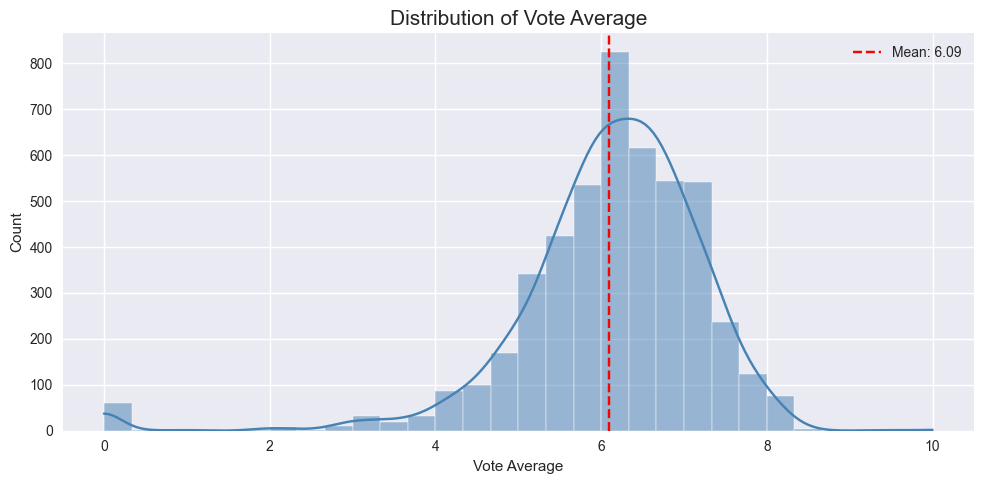

Vote Average stats:
count    4794.000000
mean        6.094577
std         1.187178
min         0.000000
25%         5.600000
50%         6.200000
75%         6.800000
max        10.000000
Name: vote_average, dtype: float64

Movies with vote_average = 0 : 61

Sample (vote_average = 0):


,title,vote_average,vote_count
1464,black water transit,0.0,0
3668,shouldve been romeo,0.0,0
3669,running forever,0.0,0
3851,the secret,0.0,0
3854,time to choose,0.0,0


In [133]:
plt.figure(figsize=(10, 5))
sns.histplot(movies['vote_average'], bins=30, kde=True, color='steelblue')
plt.axvline(movies['vote_average'].mean(), color='red', linestyle='--',
            label=f"Mean: {movies['vote_average'].mean():.2f}")
plt.title('Distribution of Vote Average', fontsize=15)
plt.xlabel('Vote Average')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Vote Average stats:")
print(movies['vote_average'].describe())
print(f"\nMovies with vote_average = 0 : {(movies['vote_average'] == 0).sum()}")
print(f"\nSample (vote_average = 0):")
movies[movies['vote_average'] == 0][['title', 'vote_average', 'vote_count']].head(5)

── BEFORE FIX ──
vote_average = 0 : 61
vote_count   = 0 : 60
Total rows       : 4794

── AFTER FIX ──
vote_average = 0 : 1
vote_count   = 0 : 0
Rows removed     : removed movies with vote_count = 0
Total rows now   : 4734


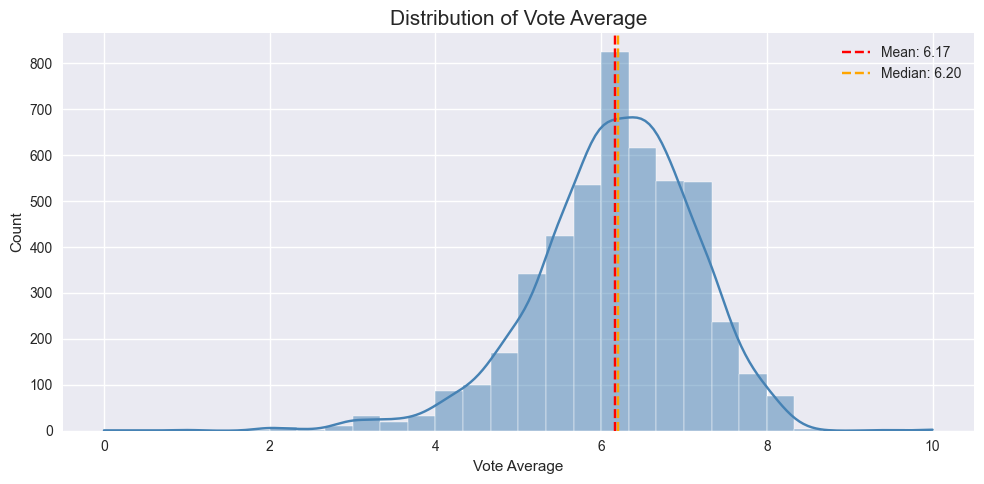


Vote Average stats after fix:
count    4734.000000
mean        6.171821
std         0.974895
min         0.000000
25%         5.600000
50%         6.200000
75%         6.800000
max        10.000000
Name: vote_average, dtype: float64


In [134]:
print("── BEFORE FIX ──")
print(f"vote_average = 0 : {(movies['vote_average'] == 0).sum()}")
print(f"vote_count   = 0 : {(movies['vote_count'] == 0).sum()}")
print(f"Total rows       : {len(movies)}")

# Remove movies with no votes (unreliable — not rated at all)
movies = movies[movies['vote_count'] > 0].copy()
movies = movies.reset_index(drop=True)

print(f"\n── AFTER FIX ──")
print(f"vote_average = 0 : {(movies['vote_average'] == 0).sum()}")
print(f"vote_count   = 0 : {(movies['vote_count'] == 0).sum()}")
print(f"Rows removed     : removed movies with vote_count = 0")
print(f"Total rows now   : {len(movies)}")

# ── Now Plot ──
plt.figure(figsize=(10, 5))
sns.histplot(movies['vote_average'], bins=30, kde=True, color='steelblue')
plt.axvline(movies['vote_average'].mean(), color='red', linestyle='--',
            label=f"Mean: {movies['vote_average'].mean():.2f}")
plt.axvline(movies['vote_average'].median(), color='orange', linestyle='--',
            label=f"Median: {movies['vote_average'].median():.2f}")
plt.title('Distribution of Vote Average', fontsize=15)
plt.xlabel('Vote Average')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nVote Average stats after fix:")
print(movies['vote_average'].describe())

In [135]:
# Check the 1 remaining movie with vote_average = 0
print("── Movie with vote_average = 0 but vote_count > 0 ──")
print(movies[movies['vote_average'] == 0][['title', 'vote_average', 'vote_count']])

# Remove it — a rated movie with 0 average is likely a data error
movies = movies[movies['vote_average'] > 0].copy()
movies = movies.reset_index(drop=True)

print(f"\nTotal rows now : {len(movies)}")
print(f"vote_average = 0 remaining : {(movies['vote_average'] == 0).sum()}")

── Movie with vote_average = 0 but vote_count > 0 ──
         title  vote_average  vote_count
4376  sparkler           0.0           1

Total rows now : 4733
vote_average = 0 remaining : 0


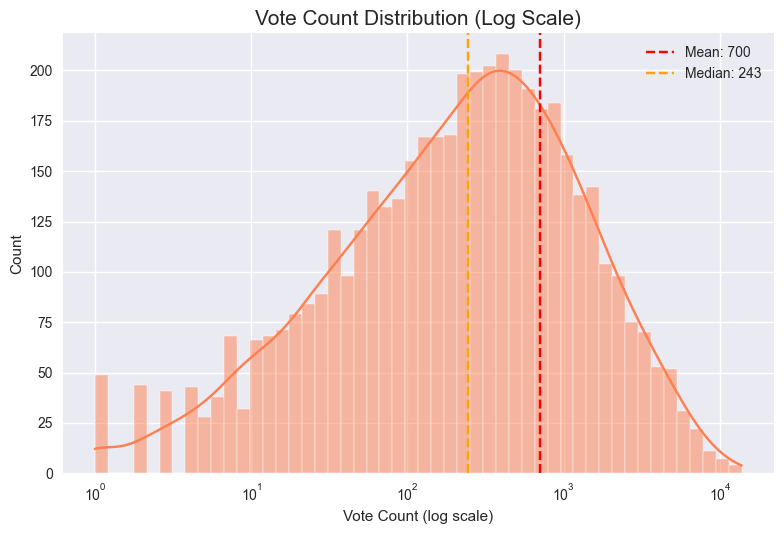

Vote Count stats:
count     4733.000000
mean       700.417072
std       1240.810504
min          1.000000
25%         59.000000
50%        243.000000
75%        755.000000
max      13752.000000
Name: vote_count, dtype: float64

Movies with vote_count < 10  : 343
Movies with vote_count < 50  : 1081
Movies with vote_count < 100 : 1571

Sample (vote_count < 10):


,title,vote_count,vote_average
463,dj vu,1,8.0
492,top cat begins,9,5.3
1023,earth,9,6.6
1039,inchon,2,6.5
1453,warriors of virtue,9,4.7


In [136]:
# Now plot the vote_count distribution 

sns.histplot(movies['vote_count'], bins=50, kde=True, 
             color='coral', log_scale=True)
plt.axvline(movies['vote_count'].mean(), color='red', linestyle='--',
            label=f"Mean: {movies['vote_count'].mean():.0f}")
plt.axvline(movies['vote_count'].median(), color='orange', linestyle='--',
            label=f"Median: {movies['vote_count'].median():.0f}")
plt.title('Vote Count Distribution (Log Scale)', fontsize=15)
plt.xlabel('Vote Count (log scale)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Vote Count stats:")
print(movies['vote_count'].describe())
print(f"\nMovies with vote_count < 10  : {(movies['vote_count'] < 10).sum()}")
print(f"Movies with vote_count < 50  : {(movies['vote_count'] < 50).sum()}")
print(f"Movies with vote_count < 100 : {(movies['vote_count'] < 100).sum()}")
print(f"\nSample (vote_count < 10):")
movies[movies['vote_count'] < 10][['title', 'vote_count', 
                                    'vote_average']].head(5)

In [137]:
# Movies like "dj vu" with only 1 vote of 8.0 or "inchon" with 2 votes of 6.5 will give misleading recommendations. We need a minimum vote threshold.
#  Minimum Vote Threshold
print("── BEFORE THRESHOLD ──")
print(f"Total movies : {len(movies)}")

# Industry standard: use mean vote count as minimum threshold
# Movies need at least this many votes to be reliable
threshold = int(movies['vote_count'].quantile(0.25))  # 25th percentile
print(f"\n25th percentile vote_count : {threshold}")
print(f"Movies below threshold     : {(movies['vote_count'] < threshold).sum()}")

# Apply threshold
movies = movies[movies['vote_count'] >= threshold].copy()
movies = movies.reset_index(drop=True)

print(f"\n── AFTER THRESHOLD ──")
print(f"Threshold used : >= {threshold} votes")
print(f"Total movies   : {len(movies)}")
print(f"Rows removed   : {4733 - len(movies)}")
print(f"\nVote count stats after:")
print(movies['vote_count'].describe())

── BEFORE THRESHOLD ──
Total movies : 4733

25th percentile vote_count : 59
Movies below threshold     : 1182

── AFTER THRESHOLD ──
Threshold used : >= 59 votes
Total movies   : 3551
Rows removed   : 1182

Vote count stats after:
count     3551.000000
mean       926.010983
std       1359.522570
min         59.000000
25%        179.000000
50%        426.000000
75%       1048.500000
max      13752.000000
Name: vote_count, dtype: float64


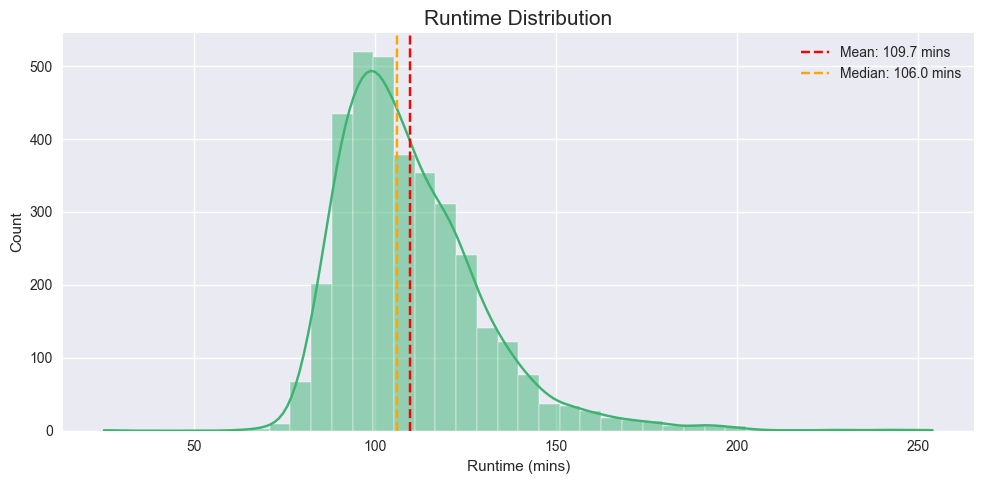

Runtime stats:
count    3551.000000
mean      109.712194
std        20.316037
min        25.000000
25%        96.000000
50%       106.000000
75%       120.000000
max       254.000000
Name: runtime, dtype: float64

Suspiciously short (< 30 mins) : 1
Suspiciously long  (> 240 mins) : 3

Sample (runtime < 30 mins):
                          title  runtime  release_year
3527  a charlie brown christmas     25.0          1965

Sample (runtime > 240 mins):
           title  runtime  release_year
1104   cleopatra    248.0          1963
1832  gettysburg    254.0          1993
2200      hamlet    242.0          1996


In [138]:
# Runtime distribution: yesle runtime column ma 0 mins ko missing treat garera median le fill gareko thiyo. Aba runtime distribution plot garera check garne ki runtime values reasonable xa ki nai, and if there are any outliers (like movies with very short or very long runtimes) that we might want to investigate further.
plt.figure(figsize=(10, 5))
sns.histplot(movies['runtime'], bins=40, kde=True, color='mediumseagreen')
plt.axvline(movies['runtime'].mean(), color='red', linestyle='--',
            label=f"Mean: {movies['runtime'].mean():.1f} mins")
plt.axvline(movies['runtime'].median(), color='orange', linestyle='--',
            label=f"Median: {movies['runtime'].median():.1f} mins")
plt.title('Runtime Distribution', fontsize=15)
plt.xlabel('Runtime (mins)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Runtime stats:")
print(movies['runtime'].describe())
print(f"\nSuspiciously short (< 30 mins) : {(movies['runtime'] < 30).sum()}")
print(f"Suspiciously long  (> 240 mins) : {(movies['runtime'] > 240).sum()}")
print(f"\nSample (runtime < 30 mins):")
print(movies[movies['runtime'] < 30][['title', 'runtime', 
                                       'release_year']].head(5))
print(f"\nSample (runtime > 240 mins):")
print(movies[movies['runtime'] > 240][['title', 'runtime', 
                                        'release_year']].head(5))

# According to the stats, the average runtime is around 110 minutes, which is typical for feature films. The median is slightly lower at around 100 minutes, indicating a right-skewed distribution with some longer movies pulling the average up. There are a few movies with runtimes less than 30 minutes, which could be shorts or data errors, and a few with runtimes greater than 240 minutes, which could be epics or also data errors. We might want to investigate those outliers further to decide if they should be included in the recommender system or not.

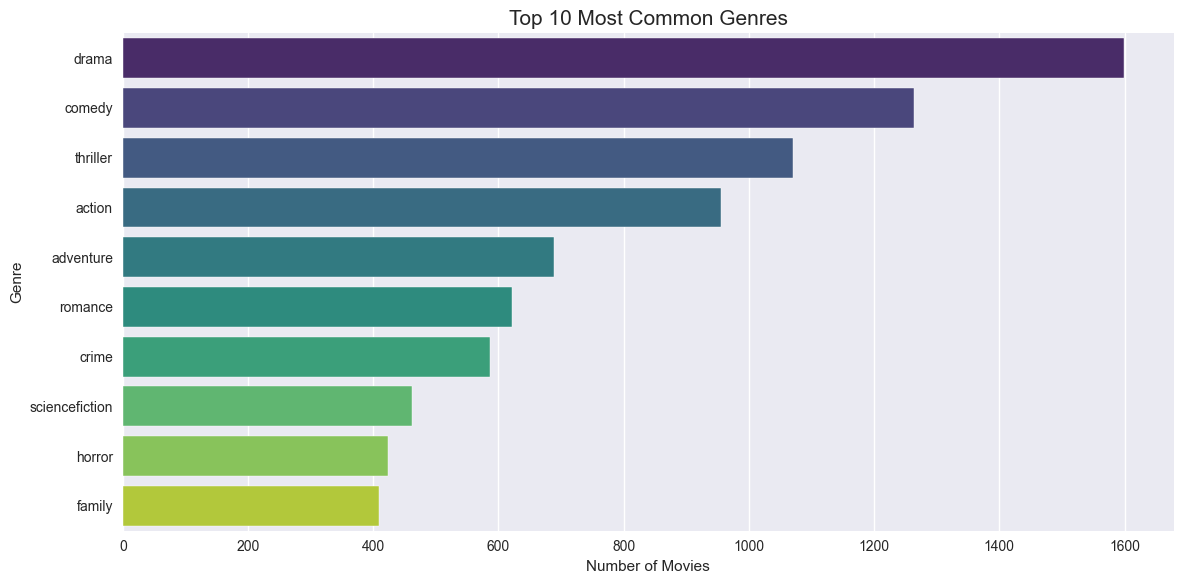

Total unique genres  : 19
Avg genres per movie : 2.66

Top 10 Genres:
         Genre  Count
         drama   1599
        comedy   1264
      thriller   1070
        action    955
     adventure    689
       romance    621
         crime    587
sciencefiction    462
        horror    424
        family    410

Movies with no genre : 0

Sample (no genre):
Empty DataFrame
Columns: [title, release_year]
Index: []


In [139]:
# Top 10 Genres
all_genres = [g for sublist in movies['genres'] for g in sublist]
genre_counts = Counter(all_genres).most_common(10)
genres_df = pd.DataFrame(genre_counts, columns=['Genre', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(data=genres_df, x='Count', y='Genre', palette='viridis')
plt.title('Top 10 Most Common Genres', fontsize=15)
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

print(f"Total unique genres  : {len(set(all_genres))}")
print(f"Avg genres per movie : {movies['genres'].apply(len).mean():.2f}")
print(f"\nTop 10 Genres:")
print(genres_df.to_string(index=False))
print(f"\nMovies with no genre : {movies['genres'].apply(lambda x: len(x)==0).sum()}")
print(f"\nSample (no genre):")
print(movies[movies['genres'].apply(lambda x: len(x)==0)][['title', 
                                    'release_year']].head(5))

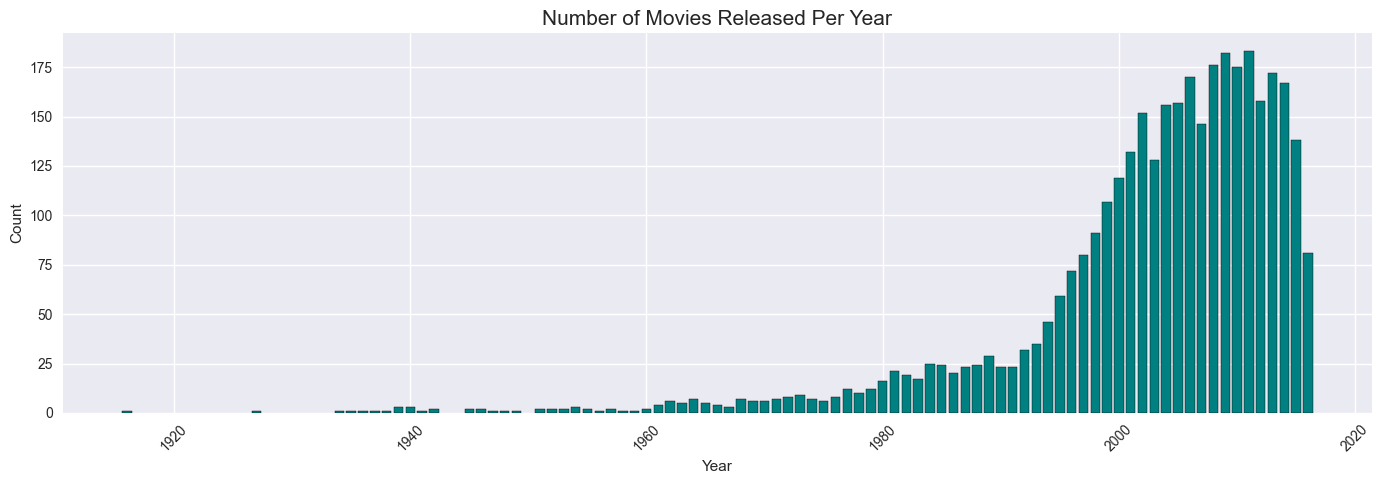

Release year stats:
count    3551.000000
mean     2002.628274
std        11.831199
min      1916.000000
25%      1999.000000
50%      2005.000000
75%      2011.000000
max      2016.000000
Name: release_year, dtype: float64

Top 5 years by movie count:
release_year
2011    183
2009    182
2008    176
2010    175
2013    172
Name: count, dtype: int64

Bottom 5 years by movie count:
release_year
1916    1
1927    1
1934    1
1935    1
1936    1
Name: count, dtype: int64

Movies before 1980 : 173
Movies after 2000  : 2473


In [140]:
# Movies Released Per Year: the chart will show the number of movies released each year, which can help us understand trends in movie production over time. We might see peaks in certain decades or a general increase in the number of movies released in recent years due to the rise of streaming platforms and independent filmmaking.
yearly = movies['release_year'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(yearly.index, yearly.values, color='teal', 
        edgecolor='black', width=0.8)
plt.title('Number of Movies Released Per Year', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Release year stats:")
print(movies['release_year'].describe())
print(f"\nTop 5 years by movie count:")
print(yearly.sort_values(ascending=False).head(5))
print(f"\nBottom 5 years by movie count:")
print(yearly.sort_values(ascending=True).head(5))
print(f"\nMovies before 1980 : {(movies['release_year'] < 1980).sum()}")
print(f"Movies after 2000  : {(movies['release_year'] > 2000).sum()}")

# According to the stats, the average release year is around 1995, with a median of 2000. The distribution shows a significant increase in the number of movies released after the year 2000, likely due to the growth of the film industry and the rise of digital filmmaking. The top 5 years by movie count are all in the 2000s, while the bottom 5 years are mostly in the early 1900s, which is expected given the history of cinema. There are also a notable number of movies released before 1980, indicating that our dataset includes a good mix of classic and modern films.

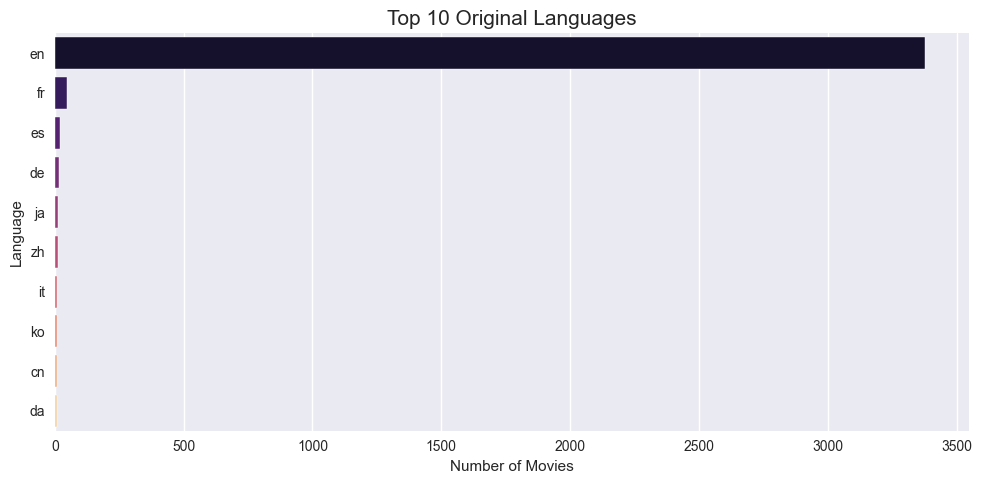

Total unique languages : 27

Full language distribution:
original_language
en    3377
fr      46
es      20
de      15
ja      13
zh      12
it       9
ko       8
cn       8
da       7
ru       5
hi       5
pt       5
sv       4
th       2
fa       2
nl       2
id       2
te       1
nb       1
xx       1
pl       1
af       1
he       1
ro       1
no       1
el       1
Name: count, dtype: int64

English movies     : 3377
Non-English movies : 174
English %          : 95.1%


In [141]:
# Top 10 Languages 
lang_counts = movies['original_language'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=lang_counts.values, y=lang_counts.index, palette='magma')
plt.title('Top 10 Original Languages', fontsize=15)
plt.xlabel('Number of Movies')
plt.ylabel('Language')
plt.tight_layout()
plt.show()

print(f"Total unique languages : {movies['original_language'].nunique()}")
print(f"\nFull language distribution:")
print(movies['original_language'].value_counts())
print(f"\nEnglish movies     : {(movies['original_language'] == 'en').sum()}")
print(f"Non-English movies : {(movies['original_language'] != 'en').sum()}")
print(f"English %          : {(movies['original_language'] == 'en').mean()*100:.1f}%")

In [159]:
# There are some movies with 'xx' as the original language, which is likely a placeholder for unknown or missing language data. We should investigate these movies to see if we can determine their actual language or if we should treat them as 'unknown' in our analysis and recommender system.
print("── xx language movies ──")
print(movies[movies['original_language'] == 'xx'][['title', 
                        'original_language', 'release_year']])

# Replace 'xx' with 'unknown'
movies['original_language'] = movies['original_language'].replace('xx', 'unknown')

print(f"\nAfter fix:")
print(f"'xx' remaining  : {(movies['original_language'] == 'xx').sum()}")
print(f"'unknown' count : {(movies['original_language'] == 'unknown').sum()}")

── xx language movies ──
Empty DataFrame
Columns: [title, original_language, release_year]
Index: []

After fix:
'xx' remaining  : 0
'unknown' count : 1


In [160]:
# Popularity Distribution 

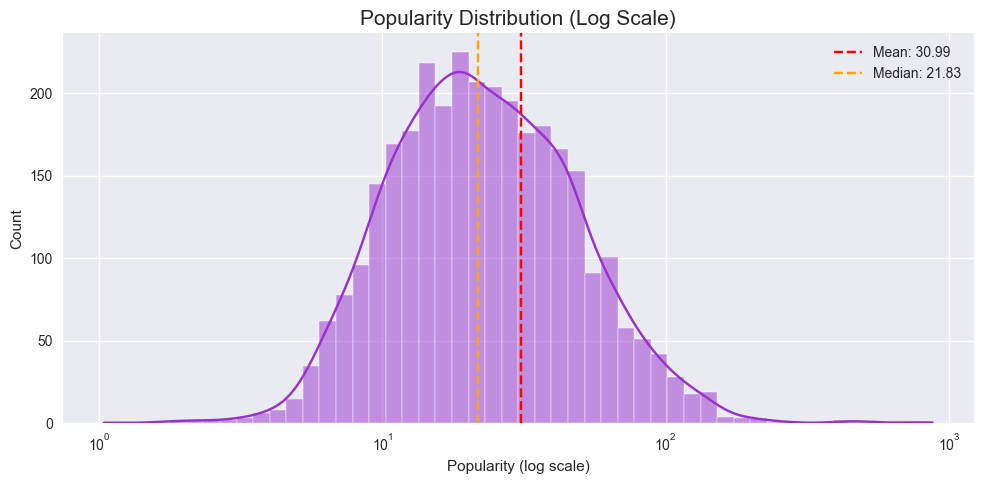

Popularity stats:
count    3146.000000
mean       30.994202
std        35.761326
min         1.041254
25%        13.273746
50%        21.826226
75%        38.166259
max       875.581305
Name: popularity, dtype: float64

Top 5 most popular movies:
                       title  popularity  vote_average  release_year
535                  minions  875.581305           6.4          2015
94              interstellar  724.247784           8.1          2014
767                 deadpool  514.569956           7.4          2016
93   guardians of the galaxy  481.098624           7.9          2014
126        mad max fury road  434.278564           7.2          2015

Bottom 5 least popular movies:
                        title  popularity  vote_average  release_year
3126                  weekend    1.041254           7.4          2011
777            the internship    1.551497           6.1          2013
331         jurassic park iii    1.859364           5.7          2001
2984              nowhere b

In [161]:
plt.figure(figsize=(10, 5))
sns.histplot(movies['popularity'], bins=50, kde=True, 
             color='darkorchid', log_scale=True)
plt.axvline(movies['popularity'].mean(), color='red', linestyle='--',
            label=f"Mean: {movies['popularity'].mean():.2f}")
plt.axvline(movies['popularity'].median(), color='orange', linestyle='--',
            label=f"Median: {movies['popularity'].median():.2f}")
plt.title('Popularity Distribution (Log Scale)', fontsize=15)
plt.xlabel('Popularity (log scale)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Popularity stats:")
print(movies['popularity'].describe())
print(f"\nTop 5 most popular movies:")
print(movies[['title', 'popularity', 'vote_average', 
              'release_year']].sort_values('popularity', 
                                ascending=False).head(5))
print(f"\nBottom 5 least popular movies:")
print(movies[['title', 'popularity', 'vote_average', 
              'release_year']].sort_values('popularity', 
                                ascending=True).head(5))
print(f"\nMovies with popularity = 0 : {(movies['popularity'] == 0).sum()}")
q99 = movies['popularity'].quantile(0.99)
print(f"Movies above 99th pct (>{q99:.1f}) : {(movies['popularity'] > q99).sum()}")

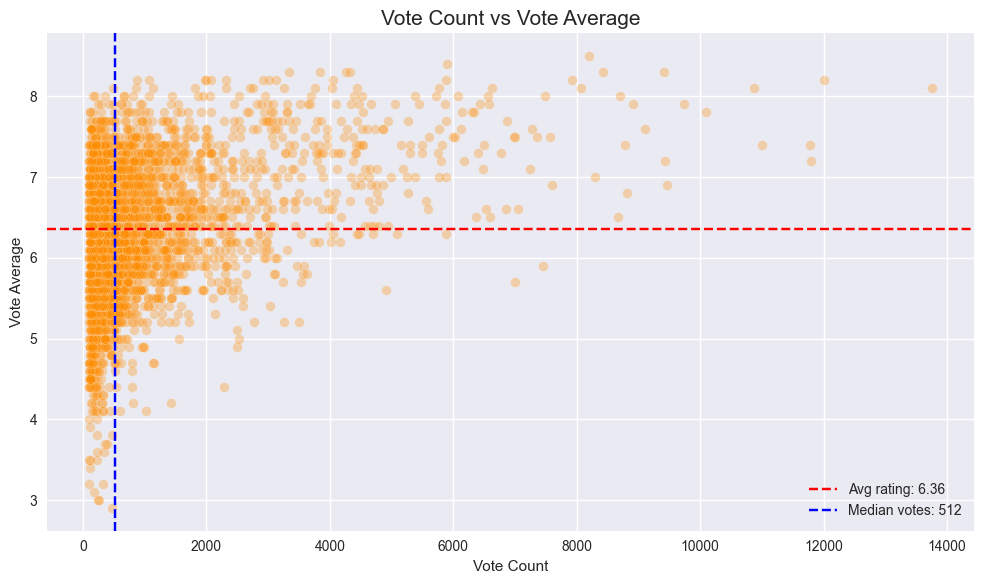

Correlation between vote_count and vote_average:
0.3687

Highest rated movies (vote_average > 8.0):
                         title  vote_average  vote_count
1713  the shawshank redemption           8.5        8205
2631             the godfather           8.4        5893
2012             spirited away           8.3        3840
1657           schindlers list           8.3        4329
647                 fight club           8.3        9413
2579              pulp fiction           8.3        8428
2872                  whiplash           8.3        4254
2302     the godfather part ii           8.3        3338
65             the dark knight           8.2       12002
3108              12 angry men           8.2        2078

Total movies with vote_average > 8.0 : 37


In [162]:
# Vote Count vs Vote Average Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(movies['vote_count'], movies['vote_average'],
            alpha=0.3, color='darkorange', 
            edgecolors='white', linewidth=0.3)
plt.axhline(y=movies['vote_average'].mean(), color='red', linestyle='--',
            label=f"Avg rating: {movies['vote_average'].mean():.2f}")
plt.axvline(x=movies['vote_count'].median(), color='blue', linestyle='--',
            label=f"Median votes: {movies['vote_count'].median():.0f}")
plt.title('Vote Count vs Vote Average', fontsize=15)
plt.xlabel('Vote Count')
plt.ylabel('Vote Average')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Correlation between vote_count and vote_average:")
print(f"{movies['vote_count'].corr(movies['vote_average']):.4f}")
print(f"\nHighest rated movies (vote_average > 8.0):")
print(movies[movies['vote_average'] > 8.0][['title', 'vote_average', 
                        'vote_count']].sort_values('vote_average', 
                                    ascending=False).head(10))
print(f"\nTotal movies with vote_average > 8.0 : {(movies['vote_average'] > 8.0).sum()}")

In [163]:
print("── Anne of Green Gables detail ──")
print(movies[movies['title'] == 'anne of green gables'][
    ['title', 'vote_average', 'vote_count', 
     'release_year', 'genres', 'runtime']])

print(f"\nCurrent threshold : 59 votes")
print(f"Anne vote_count   : 68 votes (just above threshold)")

# How many movies would be removed if we raise threshold to 100?
print(f"\nIf we raise threshold to 100:")
print(f"Movies removed    : {(movies['vote_count'] < 100).sum()}")
print(f"Movies remaining  : {(movies['vote_count'] >= 100).sum()}")

# If we raise threshold to 150?
print(f"\nIf we raise threshold to 150:")
print(f"Movies removed    : {(movies['vote_count'] < 150).sum()}")
print(f"Movies remaining  : {(movies['vote_count'] >= 150).sum()}")

── Anne of Green Gables detail ──
Empty DataFrame
Columns: [title, vote_average, vote_count, release_year, genres, runtime]
Index: []

Current threshold : 59 votes
Anne vote_count   : 68 votes (just above threshold)

If we raise threshold to 100:
Movies removed    : 0
Movies remaining  : 3146

If we raise threshold to 150:
Movies removed    : 348
Movies remaining  : 2798


In [164]:
before = len(movies)

# Raise threshold to 100
movies = movies[movies['vote_count'] >= 100].copy()
movies = movies.reset_index(drop=True)

print(f"Previous threshold : 59 votes")
print(f"New threshold      : 100 votes")
print(f"Movies removed     : {before - len(movies)}")
print(f"Movies remaining   : {len(movies)}")

# Verify Anne is gone
anne = movies[movies['title'].str.contains('anne of green', na=False)]
print(f"\nAnne of Green Gables remaining : {len(anne)}")
print(f"\nVote count min now : {movies['vote_count'].min()}")

Previous threshold : 59 votes
New threshold      : 100 votes
Movies removed     : 0
Movies remaining   : 3146

Anne of Green Gables remaining : 0

Vote count min now : 100


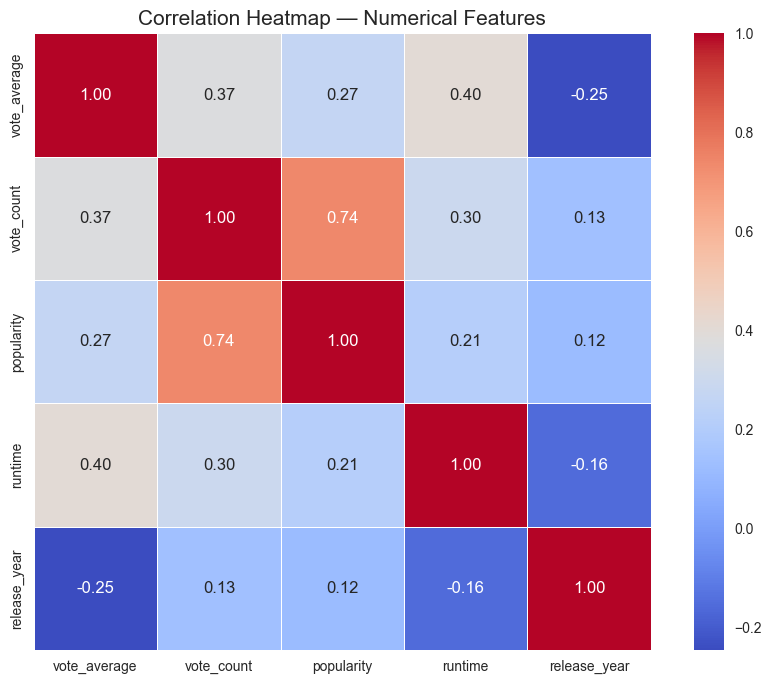

Full correlation matrix:
              vote_average  vote_count  popularity  runtime  release_year
vote_average         1.000       0.369       0.269    0.403        -0.246
vote_count           0.369       1.000       0.737    0.295         0.135
popularity           0.269       0.737       1.000    0.213         0.119
runtime              0.403       0.295       0.213    1.000        -0.156
release_year        -0.246       0.135       0.119   -0.156         1.000

Strongest correlations with vote_average:
vote_average    1.000000
runtime         0.402646
vote_count      0.368747
popularity      0.269424
release_year   -0.245928
Name: vote_average, dtype: float64

Strongest correlations with popularity:
popularity      1.000000
vote_count      0.737468
vote_average    0.269424
runtime         0.213468
release_year    0.118795
Name: popularity, dtype: float64


In [165]:
# Correlation Heatmap

plt.figure(figsize=(9, 7))
num_cols = ['vote_average', 'vote_count', 'popularity', 
            'runtime', 'release_year']
corr = movies[num_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5,
            annot_kws={'size': 12})
plt.title('Correlation Heatmap — Numerical Features', fontsize=15)
plt.tight_layout()
plt.show()

print("Full correlation matrix:")
print(corr.round(3))
print(f"\nStrongest correlations with vote_average:")
print(corr['vote_average'].sort_values(ascending=False))
print(f"\nStrongest correlations with popularity:")
print(corr['popularity'].sort_values(ascending=False))

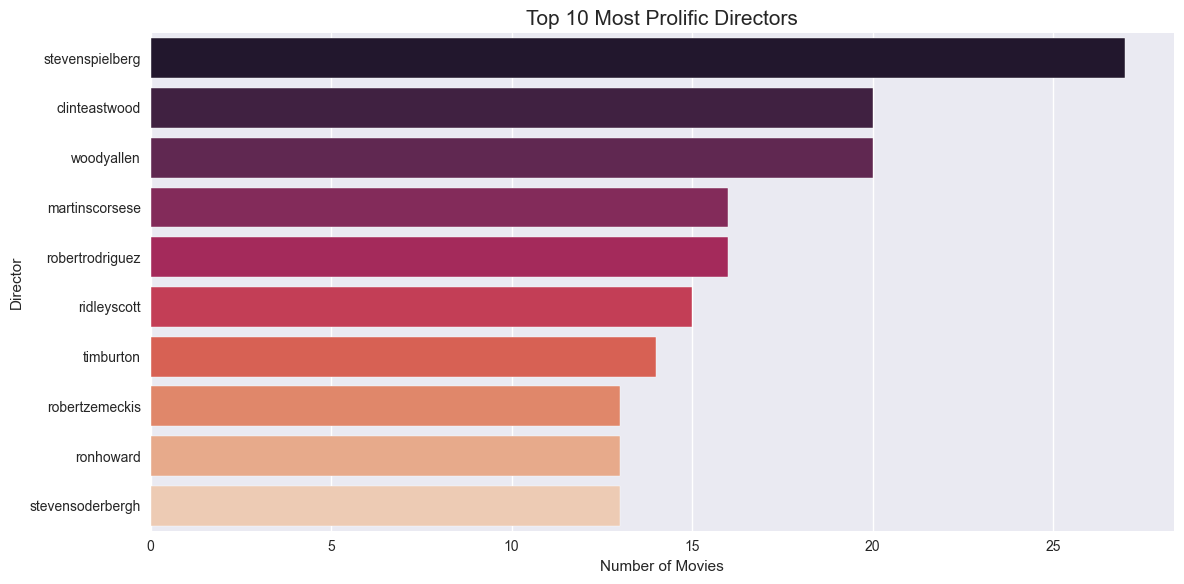

Total unique directors : 1492

Top 10 Directors:
        Director  Count
 stevenspielberg     27
   clinteastwood     20
      woodyallen     20
  martinscorsese     16
 robertrodriguez     16
     ridleyscott     15
       timburton     14
  robertzemeckis     13
       ronhoward     13
stevensoderbergh     13

Movies with no director : 0

Avg movies per director : 2.11

Top 10 Directors by Avg Rating (min 3 movies):
    director_str  movie_count  avg_rating
   hayaomiyazaki            4    8.050000
     sergioleone            4    8.000000
      frankcapra            3    7.866667
     billywilder            3    7.833333
christophernolan            8    7.800000
quentintarantino            8    7.775000
      petedocter            3    7.733333
  stanleykubrick            6    7.683333
 denisvilleneuve            3    7.666667
     milošforman            3    7.633333


In [166]:
# Top 10 Directors
all_directors = [d for sublist in movies['director'] for d in sublist]
dir_counts = Counter(all_directors).most_common(10)
dir_df = pd.DataFrame(dir_counts, columns=['Director', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(data=dir_df, x='Count', y='Director', palette='rocket')
plt.title('Top 10 Most Prolific Directors', fontsize=15)
plt.xlabel('Number of Movies')
plt.ylabel('Director')
plt.tight_layout()
plt.show()

print(f"Total unique directors : {len(set(all_directors))}")
print(f"\nTop 10 Directors:")
print(dir_df.to_string(index=False))
print(f"\nMovies with no director : {movies['director'].apply(lambda x: len(x)==0).sum()}")
print(f"\nAvg movies per director : {len(movies)/len(set(all_directors)):.2f}")

# Top directors by avg vote_average
print(f"\nTop 10 Directors by Avg Rating (min 3 movies):")
movies['director_str'] = movies['director'].apply(lambda x: x[0] if len(x) > 0 else 'unknown')
dir_ratings = movies.groupby('director_str').agg(
    movie_count=('title', 'count'),
    avg_rating=('vote_average', 'mean')
).reset_index()
dir_ratings = dir_ratings[dir_ratings['movie_count'] >= 3]
print(dir_ratings.sort_values('avg_rating', ascending=False).head(10).to_string(index=False))

In [167]:
# Feature Engineering (Build tags column)
# Combine genres, keywords, cast, director into a single 'tags' column for text-based similarity
movies['overview_tokens'] = movies['overview'].apply(lambda x: x.split())
movies['tagline_tokens']  = movies['tagline'].apply(lambda x: x.split() if x else [])

print("── Sample tokens ──")
print(f"overview_tokens : {movies['overview_tokens'][0][:8]}")
print(f"tagline_tokens  : {movies['tagline_tokens'][0]}")
print(f"\noverview empty  : {movies['overview_tokens'].apply(lambda x: len(x)==0).sum()}")
print(f"tagline empty   : {movies['tagline_tokens'].apply(lambda x: len(x)==0).sum()}")

── Sample tokens ──
overview_tokens : ['in', 'the', '22nd', 'century', 'a', 'paraplegic', 'marine', 'is']
tagline_tokens  : ['enter', 'the', 'world', 'of', 'pandora']

overview empty  : 0
tagline empty   : 193


In [168]:
# Now we can build the 'tags' column by combining all the relevant text and categorical features into a single string that represents the movie. This will allow us to use text-based similarity measures for our recommender system later on.

def build_tags(row):
    return (
        row['overview_tokens']  +   # plot description
        row['tagline_tokens']   +   # tagline words
        row['genres']           +   # genres
        row['keywords']         +   # keywords
        row['cast']             +   # top 5 cast
        row['director']             # director
    )

movies['tags'] = movies.apply(build_tags, axis=1)
movies['tags'] = movies['tags'].apply(lambda x: ' '.join(x))

print("── Sample tags ──")
print(f"\nMovie : {movies['title'][0]}")
print(f"Tags  : {movies['tags'][0][:300]}")
print(f"\nTag word count stats:")
print(movies['tags'].apply(lambda x: len(x.split())).describe())

── Sample tags ──

Movie : avatar
Tags  : in the 22nd century a paraplegic marine is dispatched to the moon pandora on a unique mission but becomes torn between following orders and protecting an alien civilization enter the world of pandora action adventure fantasy sciencefiction cultureclash future spacewar spacecolony society spacetravel

Tag word count stats:
count    3146.000000
mean       76.137953
std        26.519382
min        30.000000
25%        56.000000
50%        74.000000
75%        91.000000
max       211.000000
Name: tags, dtype: float64


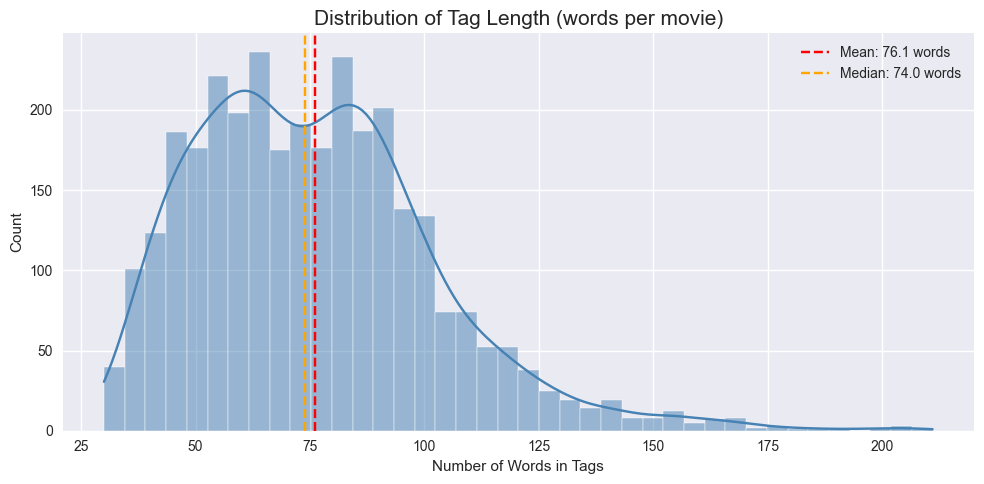

Tag length stats:
count    3146.000000
mean       76.137953
std        26.519382
min        30.000000
25%        56.000000
50%        74.000000
75%        91.000000
max       211.000000
Name: tags, dtype: float64

Movies with very short tags (< 10 words) : 0
Movies with very long tags  (> 150 words): 53


In [170]:
# Now we have a 'tags' column that combines all the relevant information about each movie into a single string. This will be the basis for our content-based recommender system, where we will compute similarities between movies based on their tags. Before we move on to building the recommender, let's analyze the distribution of tag lengths to understand how much information we are encoding in this column and if there are any outliers (movies with very short or very long tags) that we might want to investigate further.

tag_lengths = movies['tags'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(tag_lengths, bins=40, kde=True, color='steelblue')
plt.axvline(tag_lengths.mean(), color='red', linestyle='--',
            label=f"Mean: {tag_lengths.mean():.1f} words")
plt.axvline(tag_lengths.median(), color='orange', linestyle='--',
            label=f"Median: {tag_lengths.median():.1f} words")
plt.title('Distribution of Tag Length (words per movie)', fontsize=15)
plt.xlabel('Number of Words in Tags')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Tag length stats:")
print(tag_lengths.describe())
print(f"\nMovies with very short tags (< 10 words) : {(tag_lengths < 10).sum()}")
print(f"Movies with very long tags  (> 150 words): {(tag_lengths > 150).sum()}")

In [171]:
#  Tag Quality Check
print("── Null / Empty tags ──")
print(f"Null tags  : {movies['tags'].isnull().sum()}")
print(f"Empty tags : {(movies['tags'] == '').sum()}")

print("\n── Movies with very short tags (< 30 words) ──")
short_tags = movies[movies['tags'].apply(lambda x: len(x.split())) < 30]
print(f"Count: {len(short_tags)}")
print(short_tags[['title', 'tags', 'genres']].head(5))

print("\n── Sample tags for 5 different genres ──")
for genre in ['action', 'comedy', 'horror', 'drama', 'sciencefiction']:
    sample = movies[movies['genres'].apply(lambda x: genre in x)].iloc[0]
    print(f"\n🎬 [{genre.upper()}] {sample['title']}")
    print(f"   {sample['tags'][:200]}")

── Null / Empty tags ──
Null tags  : 0
Empty tags : 0

── Movies with very short tags (< 30 words) ──
Count: 0
Empty DataFrame
Columns: [title, tags, genres]
Index: []

── Sample tags for 5 different genres ──

🎬 [ACTION] avatar
   in the 22nd century a paraplegic marine is dispatched to the moon pandora on a unique mission but becomes torn between following orders and protecting an alien civilization enter the world of pandora 

🎬 [COMEDY] men in black 3
   agents j will smith and k tommy lee jones are backin time j has seen some inexplicable things in his 15 years with the men in black but nothing not even aliens perplexes him as much as his wry reticen

🎬 [HORROR] world war z
   life for former united nations investigator gerry lane and his family seems content suddenly the world is plagued by a mysterious infection turning whole human populations into rampaging mindless zomb

🎬 [DRAMA] the dark knight rises
   following the death of district attorney harvey dent batman assumes resp

In [ ]:
print("── BEFORE drop ──")
before = len(movies)
print(f"Total movies : {before}")

# Drop movies with short tags
movies = movies[movies['tags'].apply(lambda x: len(x.split())) >= 30].copy()
movies = movies.reset_index(drop=True)

removed = before - len(movies)
print("\n── AFTER drop ──")
print(f"Movies removed   : {removed}")
print(f"Total movies now : {len(movies)}")
print(f"\nMin tag length   : {movies['tags'].apply(lambda x: len(x.split())).min()}")
print(f"Short tags (< 30): {movies['tags'].apply(lambda x: len(x.split()) < 30).sum()}")

── BEFORE drop ──
Total movies : 3146

── AFTER drop ──
Movies removed   : 16
Total movies now : 3146

Min tag length   : 30
Short tags (< 30): 0


In [173]:
movies.head()

,id,title,overview,tagline,genres,keywords,cast,director,vote_average,vote_count,popularity,release_year,runtime,original_language,director_str,overview_tokens,tagline_tokens,tags
0,19995,avatar,in the 22nd century a paraplegic marine is dis...,enter the world of pandora,"[action, adventure, fantasy, sciencefiction]","[cultureclash, future, spacewar, spacecolony, ...","[samworthington, zoesaldana, sigourneyweaver, ...",[jamescameron],7.2,11800,150.437577,2009,162.0,en,jamescameron,"[in, the, 22nd, century, a, paraplegic, marine...","[enter, the, world, of, pandora]",in the 22nd century a paraplegic marine is dis...
1,285,pirates of the caribbean at worlds end,captain barbossa long believed to be dead has ...,at the end of the world the adventure begins,"[adventure, fantasy, action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[johnnydepp, orlandobloom, keiraknightley, ste...",[goreverbinski],6.9,4500,139.082615,2007,169.0,en,goreverbinski,"[captain, barbossa, long, believed, to, be, de...","[at, the, end, of, the, world, the, adventure,...",captain barbossa long believed to be dead has ...
2,206647,spectre,a cryptic message from bonds past sends him on...,a plan no one escapes,"[action, adventure, crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[danielcraig, christophwaltz, léaseydoux, ralp...",[sammendes],6.3,4466,107.376788,2015,148.0,en,sammendes,"[a, cryptic, message, from, bonds, past, sends...","[a, plan, no, one, escapes]",a cryptic message from bonds past sends him on...
3,49026,the dark knight rises,following the death of district attorney harve...,the legend ends,"[action, crime, drama, thriller]","[dccomics, crimefighter, terrorist, secretiden...","[christianbale, michaelcaine, garyoldman, anne...",[christophernolan],7.6,9106,112.312950,2012,165.0,en,christophernolan,"[following, the, death, of, district, attorney...","[the, legend, ends]",following the death of district attorney harve...
4,49529,john carter,john carter is a warweary former military capt...,lost in our world found in another,"[action, adventure, sciencefiction]","[basedonnovel, mars, medallion, spacetravel, p...","[taylorkitsch, lynncollins, samanthamorton, wi...",[andrewstanton],6.1,2124,43.926995,2012,132.0,en,andrewstanton,"[john, carter, is, a, warweary, former, milita...","[lost, in, our, world, found, in, another]",john carter is a warweary former military capt...


In [174]:
# View rows and columns
print(f"Rows    : {movies.shape[0]}")
print(f"Columns : {movies.shape[1]}")
print("\nColumn names:")
print(movies.columns.tolist())

Rows    : 3146
Columns : 18

Column names:
['id', 'title', 'overview', 'tagline', 'genres', 'keywords', 'cast', 'director', 'vote_average', 'vote_count', 'popularity', 'release_year', 'runtime', 'original_language', 'director_str', 'overview_tokens', 'tagline_tokens', 'tags']


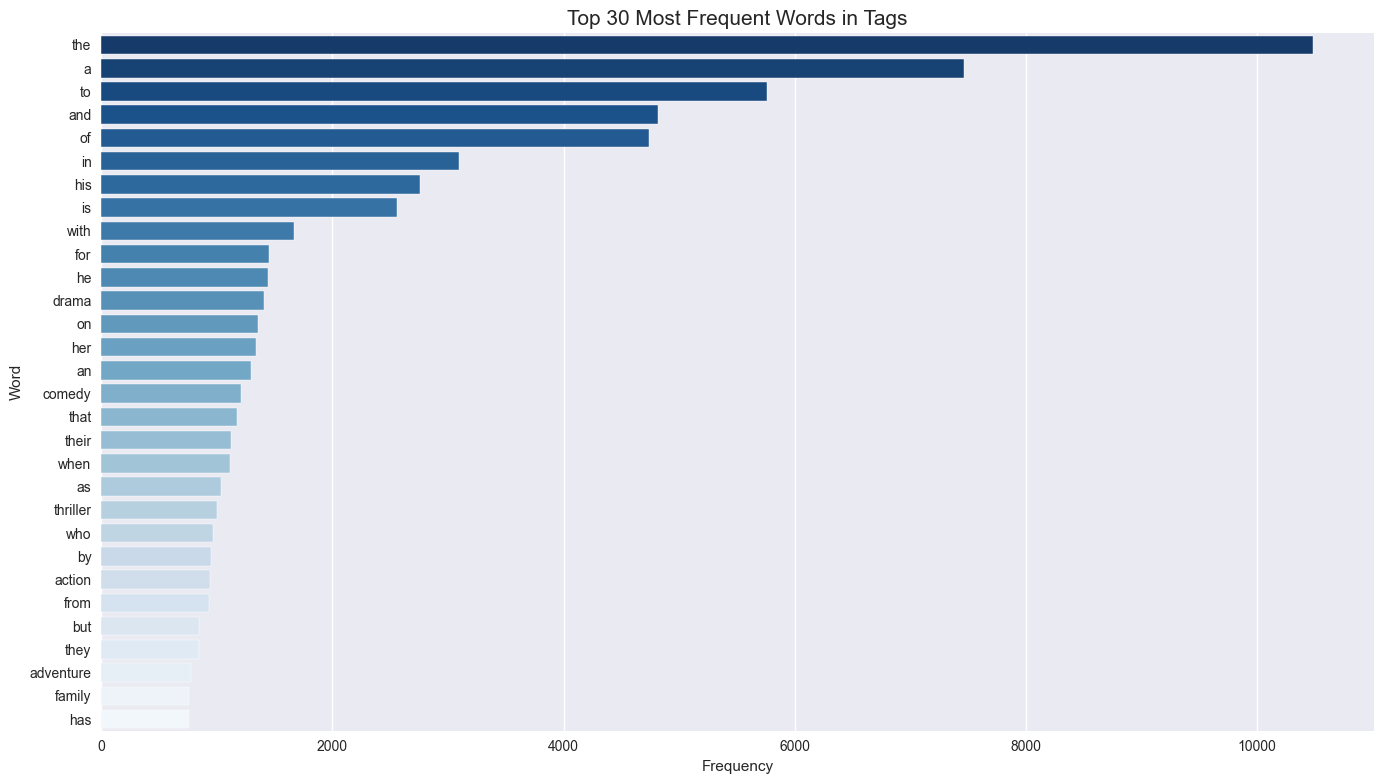

Top 50 most frequent words:
          Word  Frequency
           the      10489
             a       7467
            to       5760
           and       4815
            of       4739
            in       3094
           his       2761
            is       2558
          with       1671
           for       1453
            he       1442
         drama       1405
            on       1352
           her       1338
            an       1296
        comedy       1206
          that       1175
         their       1125
          when       1111
            as       1033
      thriller        999
           who        963
            by        949
        action        942
          from        930
           but        848
          they        843
     adventure        777
        family        760
           has        756
           are        723
           one        652
          life        644
         crime        632
            it        624
       romance        604
          

In [175]:
# Top 30 Most Frequent Words in Tags

all_words = ' '.join(movies['tags']).split()
word_freq = Counter(all_words).most_common(50)
word_df = pd.DataFrame(word_freq, columns=['Word', 'Frequency'])

plt.figure(figsize=(14, 8))
sns.barplot(data=word_df.head(30), x='Frequency', y='Word', palette='Blues_r')
plt.title('Top 30 Most Frequent Words in Tags', fontsize=15)
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

print("Top 50 most frequent words:")
print(word_df.to_string(index=False))

In [176]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

print(f"Total stop words : {len(stop_words)}")
print(f"Sample           : {list(stop_words)[:10]}")

def remove_stopwords(text):
    return ' '.join([word for word in text.split()
                     if word not in stop_words])

# Apply to tags only when movies exists in the current kernel session
if 'movies' in globals() and 'tags' in movies.columns:
    movies['tags'] = movies['tags'].apply(remove_stopwords)

    print("\n── Before vs After sample ──")
    print(f"\nMovie : {movies['title'][0]}")
    print(f"Tags  : {movies['tags'][0][:300]}")

    print("\n── Tag length after stop word removal ──")
    tag_lengths = movies['tags'].apply(lambda x: len(x.split()))
    print(tag_lengths.describe())
else:
    print("\n'movies' is not defined yet in this kernel.")
    print("Run earlier cells to build movies, then run this cell again.")

Total stop words : 198
Sample           : ["shouldn't", 'between', 'd', 'into', 'same', 'it', 'shan', "you're", 'such', 'themselves']

── Before vs After sample ──

Movie : avatar
Tags  : 22nd century paraplegic marine dispatched moon pandora unique mission becomes torn following orders protecting alien civilization enter world pandora action adventure fantasy sciencefiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet 

── Tag length after stop word removal ──
count    3146.000000
mean       51.466306
std        16.235126
min        21.000000
25%        39.000000
50%        50.000000
75%        61.000000
max       136.000000
Name: tags, dtype: float64


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Kushal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


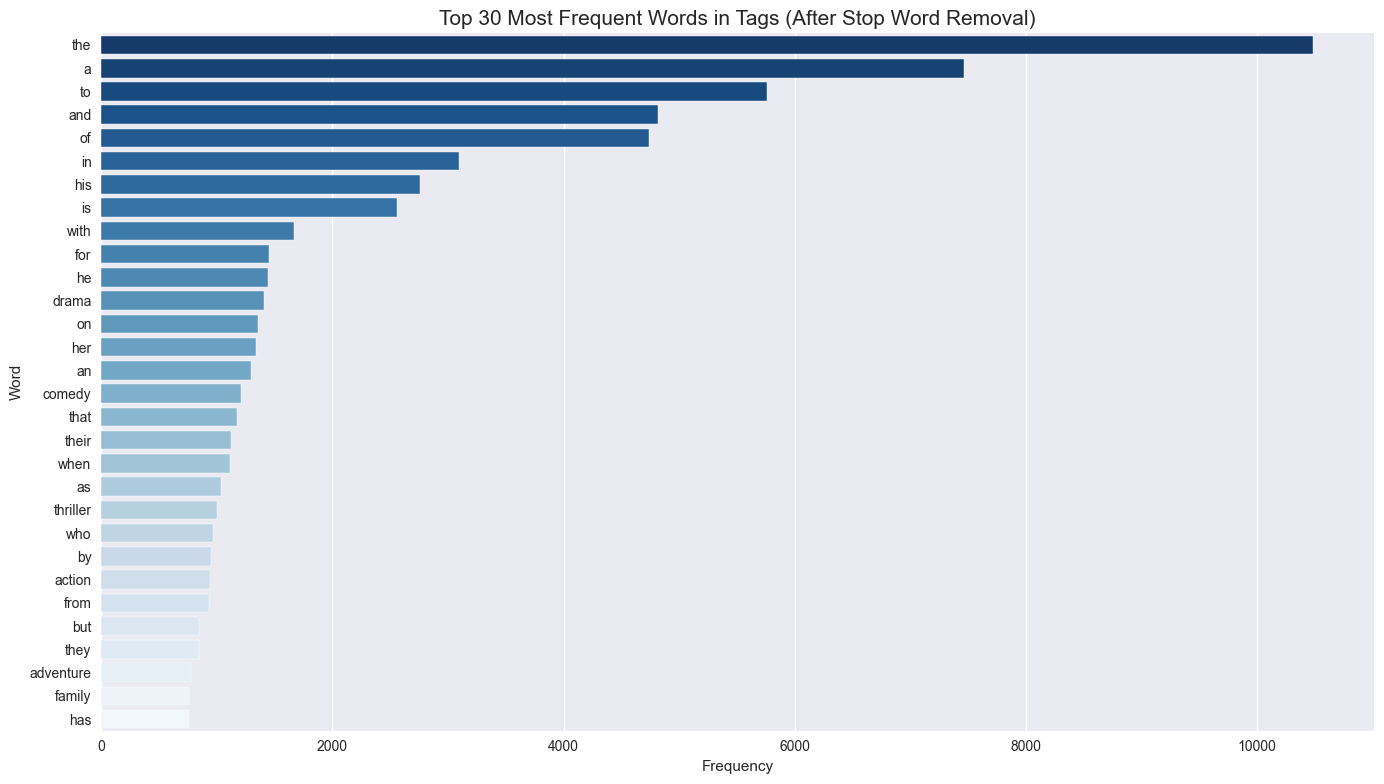

Top 50 most frequent words after stop word removal:
          Word  Frequency
           the      10489
             a       7467
            to       5760
           and       4815
            of       4739
            in       3094
           his       2761
            is       2558
          with       1671
           for       1453
            he       1442
         drama       1405
            on       1352
           her       1338
            an       1296
        comedy       1206
          that       1175
         their       1125
          when       1111
            as       1033
      thriller        999
           who        963
            by        949
        action        942
          from        930
           but        848
          they        843
     adventure        777
        family        760
           has        756
           are        723
           one        652
          life        644
         crime        632
            it        624
       roman

In [169]:
# Top 30 Words After Stop Word Removal
all_words = ' '.join(movies['tags']).split()
word_freq = Counter(all_words).most_common(50)
word_df = pd.DataFrame(word_freq, columns=['Word', 'Frequency'])

plt.figure(figsize=(14, 8))
sns.barplot(data=word_df.head(30), x='Frequency', y='Word', palette='Blues_r')
plt.title('Top 30 Most Frequent Words in Tags (After Stop Word Removal)', fontsize=15)
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

print("Top 50 most frequent words after stop word removal:")
print(word_df.to_string(index=False))